# 从海豚原始图像识别并剪裁背鳍

使用训练后的 Yolo 模型，需指定 JPG 文件夹.
结束后背鳍存在子文件夹 FIN 中，生成元数据 csv.

When the same fin are detected multiple times, try to increase the confidence.
https://github.com/ultralytics/ultralytics/issues/5811

In [1]:
import os
import glob
import cv2
import pandas as pd
from PIL import Image
from ultralytics import YOLO
from matplotlib import pyplot as plt

In [2]:
fin_detector = YOLO("models/fin_yolo_best.pt")

In [3]:
dataset_path = r'/media/filming/2025-白海豚/20240824_JM_01/'
JPG_paths = glob.glob(os.path.join(dataset_path, '*.JPG'))
JPG_paths.sort()


image 1/1 /media/filming/2025-白海豚/20240824_JM_01/1414_20240824JM01ZRA11414.JPG: 448x640 1 fin, 58.5ms
Speed: 4.0ms preprocess, 58.5ms inference, 19.6ms postprocess per image at shape (1, 3, 448, 640)


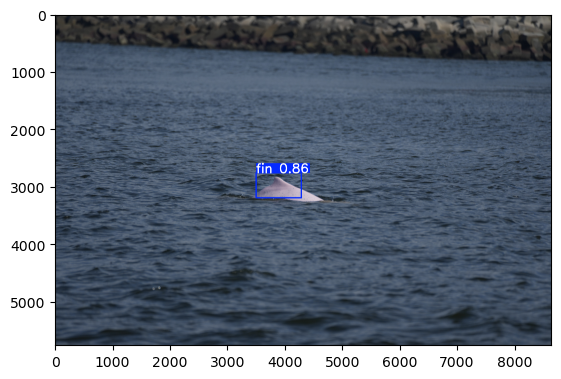

In [4]:
test_img = JPG_paths[200]
result = fin_detector(test_img)
annoted_image = result[0].plot()
annoted_image = Image.fromarray(annoted_image[..., ::-1])  # RGB-order PIL image
plt.imshow(annoted_image)

In [6]:
result[0].boxes

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([0.], device='cuda:0')
conf: tensor([0.8569], device='cuda:0')
data: tensor([[3.5032e+03, 2.7633e+03, 4.2907e+03, 3.1971e+03, 8.5695e-01, 0.0000e+00]], device='cuda:0')
id: None
is_track: False
orig_shape: (5760, 8640)
shape: torch.Size([1, 6])
xywh: tensor([[3896.9519, 2980.2219,  787.4722,  433.7656]], device='cuda:0')
xywhn: tensor([[0.4510, 0.5174, 0.0911, 0.0753]], device='cuda:0')
xyxy: tensor([[3503.2158, 2763.3391, 4290.6880, 3197.1047]], device='cuda:0')
xyxyn: tensor([[0.4055, 0.4797, 0.4966, 0.5551]], device='cuda:0')

In [7]:
fin_img_id_list = []
path_list = []
orignal_img_list =  []
orig_img_w_list = []
orig_img_h_list = []
x_min_list = []
x_max_list = []
y_min_list = []
y_max_list = []
conf_list = []

for JPG_path  in JPG_paths:
    ori_img_name = os.path.basename(JPG_path)
    results = fin_detector(JPG_path)
    for result in results:
        boxes = result.boxes
        # todo: filter the same fin which are detected multiple times.
        for fin_idx in range(boxes.shape[0]):
            xyxy = boxes[fin_idx].xyxy
            x0, y0, x1, y1 = [int(i) for i in boxes.xyxy[fin_idx]]
            x_min_list.append(x0)
            y_min_list.append(y0)
            x_max_list.append(x1)
            y_max_list.append(y1)
            conf = result.boxes[fin_idx].conf
            conf_list.append(float(conf))
            cropped_img = result.orig_img[y0:y1, x0:x1, :]
            save_dir = dataset_path + "/FIN/"
            os.makedirs(save_dir, exist_ok=True)
            img_name = ori_img_name[0:len(ori_img_name)-4] + "_FIN%02d.JPG"%fin_idx
            orignal_img_list.append( ori_img_name ) 
            path_list.append( "FIN/" + img_name )
            cv2.imwrite(save_dir+img_name, cropped_img)

            orig_img_h, orig_img_w = result[0].boxes.orig_shape
            orig_img_h_list.append(orig_img_h)
            orig_img_w_list.append(orig_img_w)

fin_img_id_list = range(len(path_list))
meta_info = pd.DataFrame({"img_id":fin_img_id_list, "path":path_list, 
                         "x_min":x_min_list, "x_max":x_max_list, "y_min":y_min_list, "y_max":y_max_list,
                        "orig_img": orignal_img_list, "crop_conf": conf_list, 
                         "orig_img_h":orig_img_h_list, "orig_img_w": orig_img_w_list})
meta_info.to_csv(dataset_path + "FIN_METAINFO.csv")


image 1/1 /media/filming/2025-白海豚/20240824_JM_01/1214_20240824JM01ZRA11214.JPG: 448x640 1 fin, 12.4ms
Speed: 35.9ms preprocess, 12.4ms inference, 0.5ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /media/filming/2025-白海豚/20240824_JM_01/1215_20240824JM01ZRA11215.JPG: 448x640 1 fin, 12.1ms
Speed: 2.8ms preprocess, 12.1ms inference, 0.4ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /media/filming/2025-白海豚/20240824_JM_01/1216_20240824JM01ZRA11216.JPG: 448x640 1 fin, 12.1ms
Speed: 3.1ms preprocess, 12.1ms inference, 0.4ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /media/filming/2025-白海豚/20240824_JM_01/1217_20240824JM01ZRA11217.JPG: 448x640 1 fin, 11.9ms
Speed: 2.8ms preprocess, 11.9ms inference, 0.4ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /media/filming/2025-白海豚/20240824_JM_01/1218_20240824JM01ZRA11218.JPG: 448x640 1 fin, 11.3ms
Speed: 2.9ms preprocess, 11.3ms inference, 0.4ms postprocess per image at shape (1, 3, 448, 640)

In [63]:
fin_img_id_list = range(len(path_list))
meta_info = pd.DataFrame({"img_id":fin_img_id_list, "path":path_list, 
                         "x_min":x_min_list, "x_max":x_max_list, "y_min":y_min_list, "y_max":y_max_list,
                        "orig_img": orignal_img_list, "crop_conf": conf_list, 
                         "orig_img_h":orig_img_h_list, "orig_img_w": orig_img_w_list})
meta_info.to_csv(dataset_path + "FIN_METAINFO.csv")

In [8]:
ret =fin_detector(dataset_path+ "/0283_20240824JM01ZRA10283.JPG")


image 1/1 /media/filming/2025-白海豚/20240824_JM_01/0283_20240824JM01ZRA10283.JPG: 448x640 2 fins, 11.7ms
Speed: 15.3ms preprocess, 11.7ms inference, 0.4ms postprocess per image at shape (1, 3, 448, 640)


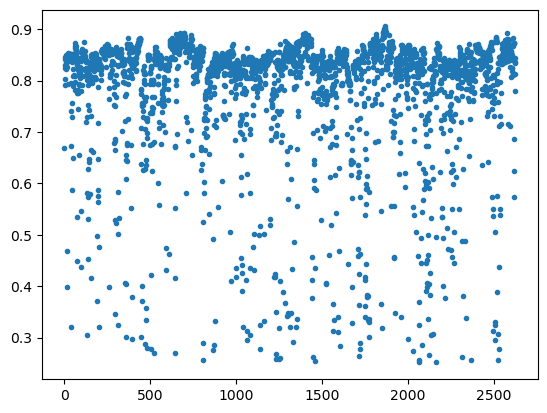

In [20]:
plt.plot(meta_info.crop_conf, ".")

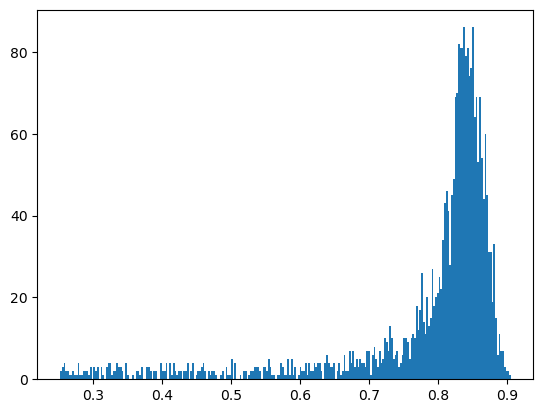

In [27]:
plt.hist(meta_info.crop_conf, bins=256)
plt.show()